# 03 — Exploración: Adiciones SECOP II

**Fuente**: `adiciones` (Dataset ID: `cb9c-h8sn`)

**Objetivo**: Explorar las modificaciones contractuales registradas en SECOP II. Este dataset contiene eventos de cambio sobre contratos ya firmados: adiciones en valor, extensiones de plazo, modificaciones al objeto, etc.

**Granularidad**: 1 fila = 1 evento de modificación sobre un contrato.

**Columnas disponibles** (5):
| Campo API | Tipo | Descripción |
|---|---|---|
| `identificador` | Texto | ID único del evento de modificación |
| `Id contrato` | Texto | ID del contrato modificado |
| `tipo` | Texto | Tipo de modificación (adición en valor, tiempo, etc.) |
| `descripción` | Texto | Justificación detallada de la modificación |
| `Fecha registro` | Marca de tiempo | Fecha de la modificación |

**Estrategia de descarga**: El dataset completo es muy grande (millones de registros de todos los tipos de contrato). En lugar de descargar todo, **filtramos directamente desde la API** usando los `id_contrato` de contratos de Obra que ya tenemos en el parquet de `contratosElectronicos`.

**Llave de integración**: `Id contrato` (adiciones) = `id_contrato` (contratosElectronicos)

---

## 1. Configuración

Importamos las librerías necesarias y definimos las constantes de conexión a la API Socrata.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sodapy import Socrata
import warnings
import re
from collections import Counter

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# Constantes de conexión
APP_TOKEN = 'nrnMDVHrooMY3wZIGrYfPsAq3'
DATASET_ID = 'cb9c-h8sn'
DOMAIN = 'www.datos.gov.co'

# Ruta de datos
DATA_DIR = '../data/'

print('Configuración lista.')
print(f'Dataset: {DATASET_ID} (Adiciones SECOP II)')

Configuración lista.
Dataset: cb9c-h8sn (Adiciones SECOP II)


## 2. Carga de IDs de contratos de Obra

Antes de descargar adiciones, cargamos los IDs de contratos de Obra desde nuestro parquet. Así podremos **filtrar directamente desde la API** y descargar solo las adiciones relevantes, en lugar de traer todo el dataset (que es muy grande).

Estrategia: consultar la API con `WHERE "Id contrato" IN (...)` en lotes de IDs.

In [2]:
# Cargar contratos de Obra para obtener sus IDs
df_contratos = pd.read_parquet(DATA_DIR + 'contratos_electronicos_obra.parquet')
obra_ids = df_contratos['id_contrato'].dropna().unique().tolist()
print(f'Contratos de Obra cargados: {len(df_contratos):,}')
print(f'IDs únicos de contrato: {len(obra_ids):,}')
print()
print('Ejemplos de IDs:')
for cid in obra_ids[:5]:
    print(f'  {cid}')

Contratos de Obra cargados: 51,353
IDs únicos de contrato: 48,331

Ejemplos de IDs:
  CO1.PCCNTR.1001032
  CO1.PCCNTR.1001046
  CO1.PCCNTR.1001111
  CO1.PCCNTR.1001129
  CO1.PCCNTR.1001240


## 3. Descarga filtrada desde la API

Descargamos solo las adiciones que corresponden a contratos de Obra. Enviamos consultas a la API Socrata con filtro `WHERE "Id contrato" IN (...)`, procesando los IDs en lotes para no exceder el límite de longitud de la URL.

Cada lote envía ~200 IDs a la vez. Con ~48,000 IDs únicos, esto genera ~240 consultas, pero cada una devuelve pocos registros, lo que es más eficiente que descargar millones de registros sin filtrar.

In [3]:
import time

client = Socrata(DOMAIN, APP_TOKEN, timeout=120)

# Función con reintentos
def fetch_with_retry(client, dataset_id, max_retries=5, **kwargs):
    for attempt in range(max_retries):
        try:
            return client.get(dataset_id, **kwargs)
        except Exception as e:
            if attempt < max_retries - 1:
                wait = 10 * (attempt + 1)
                print(f'    Error: {type(e).__name__}. Reintentando en {wait}s... (intento {attempt+2}/{max_retries})')
                time.sleep(wait)
            else:
                raise

# Paso 1: Descargar 1 registro para descubrir los nombres reales de los campos
sample = fetch_with_retry(client, DATASET_ID, limit=1)
api_columns = list(sample[0].keys())
print('Nombres reales de los campos en la API:')
for col in api_columns:
    print(f'  "{col}"')
print()

# Identificar el campo de contrato (buscar el que contenga "contrato")
id_contrato_field = None
for col in api_columns:
    if 'contrato' in col.lower():
        id_contrato_field = col
        break

print(f'Campo de ID contrato identificado: "{id_contrato_field}"')
print(f'Valor ejemplo: {sample[0].get(id_contrato_field, "N/A")}')
print()

# Paso 2: Descargar adiciones filtradas por lotes de IDs de contratos de Obra
chunk_size = 150  # IDs por consulta
all_records = []
total_chunks = (len(obra_ids) + chunk_size - 1) // chunk_size

print(f'IDs de contratos de Obra: {len(obra_ids):,}')
print(f'Lotes de {chunk_size} IDs: {total_chunks}')
print()

for i in range(0, len(obra_ids), chunk_size):
    chunk = obra_ids[i:i+chunk_size]
    chunk_num = i // chunk_size + 1
    
    # Construir cláusula WHERE
    ids_str = ", ".join([f"'{cid}'" for cid in chunk])
    where_clause = f'{id_contrato_field} IN ({ids_str})'
    
    # Descargar todas las adiciones para este lote
    offset = 0
    while True:
        batch = fetch_with_retry(client, DATASET_ID, where=where_clause, limit=50000, offset=offset)
        if not batch:
            break
        all_records.extend(batch)
        if len(batch) < 50000:
            break
        offset += 50000
    
    if chunk_num % 20 == 0 or chunk_num == total_chunks:
        print(f'  Lote {chunk_num}/{total_chunks} — Registros acumulados: {len(all_records):,}')

df = pd.DataFrame.from_records(all_records)
print()
print(f'Descarga completa: {len(df):,} registros de adiciones para contratos de Obra')
print(f'Columnas: {len(df.columns)}')

Nombres reales de los campos en la API:
  "identificador"
  "id_contrato"
  "tipo"
  "descripcion"
  "fecharegistro"

Campo de ID contrato identificado: "id_contrato"
Valor ejemplo: CO1.PCCNTR.285227

IDs de contratos de Obra: 48,331
Lotes de 150 IDs: 323



  Lote 20/323 — Registros acumulados: 15,856


  Lote 40/323 — Registros acumulados: 30,137


  Lote 60/323 — Registros acumulados: 45,152


  Lote 80/323 — Registros acumulados: 64,892


...

  Lote 280/323 — Registros acumulados: 228,437


  Lote 300/323 — Registros acumulados: 240,258


  Lote 320/323 — Registros acumulados: 248,149


  Lote 323/323 — Registros acumulados: 249,037



Descarga completa: 249,037 registros de adiciones para contratos de Obra
Columnas: 5


## 4. Exploración general

Revisamos la estructura básica del DataFrame: columnas recibidas, tipos de datos, primeras filas y estadísticas de nulidad.

**Nota**: Los datos ya están filtrados a contratos de Obra desde la descarga. No fue necesario descargar todo el dataset.

In [4]:
print('=== FORMA DEL DATASET ===')
print(f'Filas: {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
print()

print('=== COLUMNAS RECIBIDAS ===')
for i, col in enumerate(df.columns, 1):
    print(f'  {i}. "{col}" (dtype: {df[col].dtype})')
print()

print('=== NULIDAD ===')
for col in df.columns:
    nulls = df[col].isna().sum()
    pct = nulls / len(df) * 100
    print(f'  {col}: {nulls:,} nulos ({pct:.1f}%)')
print()

print('=== VALORES ÚNICOS ===')
for col in df.columns:
    print(f'  {col}: {df[col].nunique():,} valores únicos')

=== FORMA DEL DATASET ===
Filas: 249,037
Columnas: 5

=== COLUMNAS RECIBIDAS ===
  1. "identificador" (dtype: str)
  2. "id_contrato" (dtype: str)
  3. "tipo" (dtype: str)
  4. "descripcion" (dtype: str)
  5. "fecharegistro" (dtype: str)

=== NULIDAD ===
  identificador: 0 nulos (0.0%)
  id_contrato: 0 nulos (0.0%)
  tipo: 0 nulos (0.0%)
  descripcion: 0 nulos (0.0%)
  fecharegistro: 0 nulos (0.0%)

=== VALORES ÚNICOS ===
  identificador: 143,201 valores únicos
  id_contrato: 33,465 valores únicos
  tipo: 8 valores únicos
  descripcion: 102,053 valores únicos
  fecharegistro: 658 valores únicos


### 3.1 Primeros registros

Visualizamos las primeras 10 filas para entender la estructura real de los datos y el formato de cada campo.

In [5]:
df.head(10)

,identificador,id_contrato,tipo,descripcion,fecharegistro
0,CO1.CTRMOD.5495732,CO1.PCCNTR.1001032,No definido,SE AGOTO EL OBJETO CONTRACTUAL,2021-01-02T00:00:00.000
1,CO1.CTRMOD.5493885,CO1.PCCNTR.1001032,No definido,SE AGOTo EL OBJETO CONTRACTUAL,2021-01-02T00:00:00.000
2,CO1.CTRMOD.1651842,CO1.PCCNTR.1001032,MODIFICACION GENERAL,LA MODIFICACIoN 002 SE REQUIERE CON EL FIN DE INCLUIR ACTIVIDADES NUEVAS AL CONTRATO PN MEMAZ N°...,2019-01-01T00:00:00.000
3,CO1.CTRMOD.1378734,CO1.PCCNTR.1001032,MODIFICACION GENERAL,DEBIDO A QUE YA SE ENCUENTRA RECAUDADO PRESUPUESTO PARA LA ADICIoN POR VALOR $ 214.447.231;16 Y ...,2019-08-02T00:00:00.000
4,CO1.CTRMOD.14779610,CO1.PCCNTR.1001046,CONCLUSION,ACTA DE CIERRE -NO. 0078-2019\t\t\nACTA DE LIQUIDACIoN NO.0078-2019,2024-02-02T00:00:00.000
5,CO1.CTRMOD.1758352,CO1.PCCNTR.1001046,MODIFICACION GENERAL,MODIFICACIoN DEL ANEXO TeCNICO DEL CONTRATO; ASi MISMO PRORROGAR EL PLAZO DE EJECUCIoN HASTA EL ...,2019-01-01T00:00:00.000
6,CO1.CTRMOD.14779610,CO1.PCCNTR.1001046,CONCLUSION,Sin Descripción,2024-02-02T00:00:00.000
7,CO1.CTRMOD.14779610,CO1.PCCNTR.1001046,CONCLUSION,Sin Descripción,2024-02-02T00:00:00.000
8,CO1.CTRMOD.1604602,CO1.PCCNTR.1001046,MODIFICACION GENERAL,TENIENDO EN CUENTA ESCRITO FECHADO 21 DE OCTUBRE DE 2019 POR EL CONTRATISTA EN EL QUE SOLICITA A...,2019-01-01T00:00:00.000
9,CO1.CTRMOD.14779610,CO1.PCCNTR.1001046,CONCLUSION,ACTA DE CIERRE -NO. 0078-2019\t\t\nACTA DE LIQUIDACIoN NO.0078-2019,2024-02-02T00:00:00.000


### 3.2 Verificación de campos tipo diccionario

La API Socrata a veces devuelve campos como diccionarios (ej: URLs). Verificamos si alguna columna tiene este problema y la limpiamos.

In [6]:
dict_cols = []
for col in df.columns:
    if df[col].apply(type).eq(dict).any():
        dict_cols.append(col)
        print(f'Columna "{col}" contiene diccionarios.')
        print(f'  Ejemplo: {df[col].dropna().iloc[0]}')
        print()

if not dict_cols:
    print('Ninguna columna contiene diccionarios. Los datos están limpios en ese aspecto.')
else:
    for col in dict_cols:
        df[col] = df[col].apply(lambda x: x.get('url', str(x)) if isinstance(x, dict) else x)
    print('Columnas con diccionarios convertidas a texto.')

Ninguna columna contiene diccionarios. Los datos están limpios en ese aspecto.


### 3.3 Detección de sentinelas "No Definido"

SECOP II utiliza textos como "No Definido", "No definido", "Sin Descripcion" en lugar de valores nulos reales. Verificamos su presencia para calcular la nulidad real.

In [7]:
sentinels = ['No Definido', 'No definido', 'NO DEFINIDO', 'No D', 'Sin Descripcion', 'N/A', 'NA', '']

print('=== SENTINELAS DETECTADOS ===')
for col in df.columns:
    if df[col].dtype == 'object':
        for sentinel in sentinels:
            count = (df[col] == sentinel).sum()
            if count > 0:
                pct = count / len(df) * 100
                print(f'  "{col}": valor "{sentinel}" aparece {count:,} veces ({pct:.1f}%)')

print()
print('=== NULIDAD REAL (nulos + sentinelas) ===')
for col in df.columns:
    null_count = df[col].isna().sum()
    if df[col].dtype == 'object':
        sentinel_count = df[col].isin(sentinels).sum()
    else:
        sentinel_count = 0
    total_null = null_count + sentinel_count
    pct = total_null / len(df) * 100
    print(f'  {col}: {total_null:,} ({pct:.1f}%) [nulos: {null_count:,}, sentinelas: {sentinel_count:,}]')

=== SENTINELAS DETECTADOS ===

=== NULIDAD REAL (nulos + sentinelas) ===
  identificador: 0 (0.0%) [nulos: 0, sentinelas: 0]
  id_contrato: 0 (0.0%) [nulos: 0, sentinelas: 0]
  tipo: 0 (0.0%) [nulos: 0, sentinelas: 0]
  descripcion: 0 (0.0%) [nulos: 0, sentinelas: 0]
  fecharegistro: 0 (0.0%) [nulos: 0, sentinelas: 0]


## 4. Análisis de duplicados

Verificamos si hay registros duplicados por `identificador` (que debería ser único por evento de modificación) y por combinaciones de campos.

In [8]:
print('=== DUPLICADOS ===')

# Duplicados por identificador (debería ser PK)
if 'identificador' in df.columns:
    dup_id = df['identificador'].duplicated().sum()
    print(f'Duplicados en "identificador": {dup_id:,} de {len(df):,} ({dup_id/len(df)*100:.2f}%)')
    if dup_id > 0:
        top_dup = df['identificador'].value_counts().head(5)
        print(f'  IDs más repetidos:')
        for idx, count in top_dup.items():
            print(f'    {idx}: {count} veces')
    print()

# Duplicados por fila completa
dup_full = df.duplicated().sum()
print(f'Filas completamente duplicadas: {dup_full:,} ({dup_full/len(df)*100:.2f}%)')
print()

# Verificar formato del identificador
if 'identificador' in df.columns:
    print('=== FORMATO DEL IDENTIFICADOR ===')
    sample_ids = df['identificador'].dropna().head(10).tolist()
    for sid in sample_ids:
        print(f'  {sid}')

=== DUPLICADOS ===
Duplicados en "identificador": 105,836 de 249,037 (42.50%)
  IDs más repetidos:
    CO1.CTRMOD.22017406: 105 veces
    CO1.CTRMOD.21997401: 69 veces
    CO1.CTRMOD.21841374: 68 veces
    CO1.CTRMOD.21992315: 59 veces
    CO1.CTRMOD.22053595: 57 veces

Filas completamente duplicadas: 96,942 (38.93%)

=== FORMATO DEL IDENTIFICADOR ===
  CO1.CTRMOD.5495732
  CO1.CTRMOD.5493885
  CO1.CTRMOD.1651842
  CO1.CTRMOD.1378734
  CO1.CTRMOD.14779610
  CO1.CTRMOD.1758352
  CO1.CTRMOD.14779610
  CO1.CTRMOD.14779610
  CO1.CTRMOD.1604602
  CO1.CTRMOD.14779610


## 5. Análisis de la columna `tipo` (Tipo de modificación)

Esta es la columna más importante para entender qué tipos de cambios se hacen a los contratos. Los valores posibles incluyen adiciones en valor, extensiones de tiempo, modificaciones al objeto, etc.

Esto es fundamental para nuestro modelo porque:
- Las **adiciones en valor** son indicador de sobrecostos
- Las **extensiones de tiempo** son indicador de atrasos
- Ambas son potenciales **variables target**

In [9]:
# Determinar el nombre exacto de la columna tipo
tipo_col = None
for col in df.columns:
    if col.lower() == 'tipo':
        tipo_col = col
        break

if tipo_col is None:
    print('ADVERTENCIA: No se encontró columna "tipo". Columnas disponibles:')
    print(df.columns.tolist())
else:
    print(f'=== TIPOS DE MODIFICACIÓN (columna: "{tipo_col}") ===')
    tipo_counts = df[tipo_col].value_counts(dropna=False)
    print()
    total = len(df)
    for tipo, count in tipo_counts.items():
        pct = count / total * 100
        print(f'  {tipo}: {count:,} ({pct:.1f}%)')
    print(f'\n  Total de tipos distintos: {df[tipo_col].nunique()}')

=== TIPOS DE MODIFICACIÓN (columna: "tipo") ===

  MODIFICACION GENERAL: 124,918 (50.2%)
  No definido: 43,038 (17.3%)
  REACTIVACIoN: 31,802 (12.8%)
  SUSPENSIoN: 29,834 (12.0%)
  CONCLUSION: 10,683 (4.3%)
  ADICION EN EL VALOR: 7,672 (3.1%)
  CESION: 1,088 (0.4%)
  EXTENSION: 2 (0.0%)

  Total de tipos distintos: 8


### 5.1 Gráfico: Distribución de tipos de modificación

**Gráfico de barras horizontales** que muestra la frecuencia de cada tipo de modificación contractual.

- **Eje X (horizontal)**: Cantidad de registros — cada barra representa cuántos eventos de ese tipo existen en todo el dataset.
- **Eje Y (vertical)**: Tipo de modificación — categorías como "Adición en el valor del contrato", "Prórroga", etc.
- **Interpretación**: Los tipos más frecuentes indican los cambios contractuales más comunes en SECOP II. Por ejemplo, si las prórrogas dominan, significa que las extensiones de tiempo son más frecuentes que las adiciones en valor.

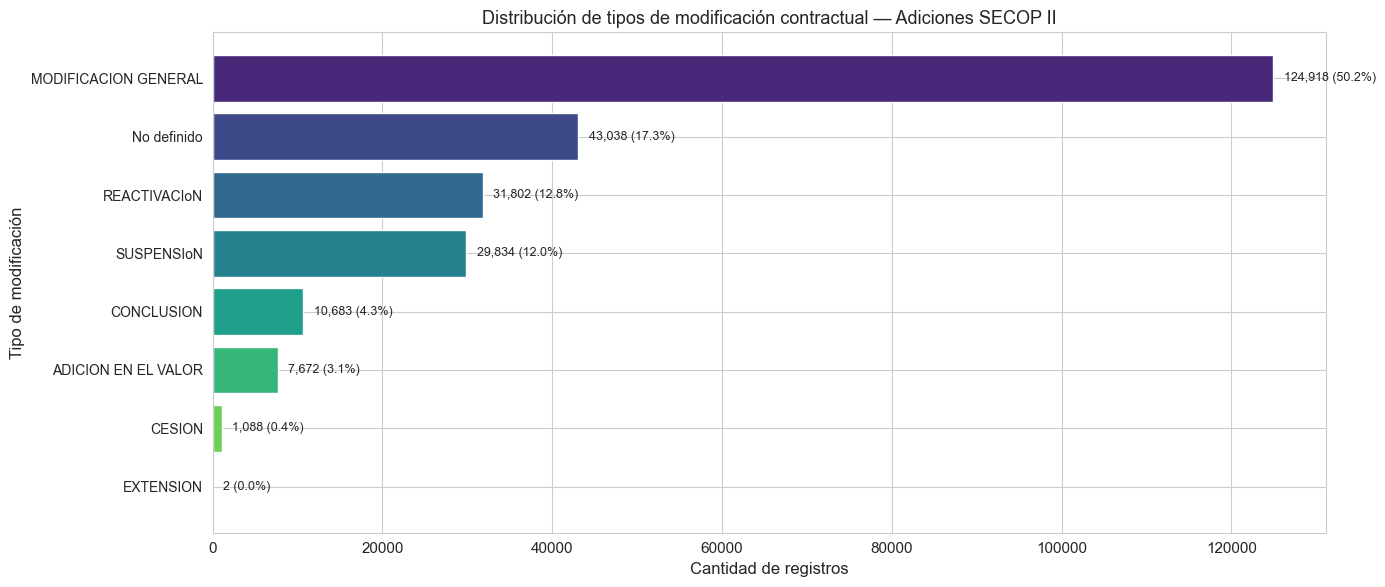

In [10]:
if tipo_col:
    fig, ax = plt.subplots(figsize=(14, max(6, df[tipo_col].nunique() * 0.6)))
    tipo_counts = df[tipo_col].value_counts()
    bars = ax.barh(range(len(tipo_counts)), tipo_counts.values, color=sns.color_palette('viridis', len(tipo_counts)))
    ax.set_yticks(range(len(tipo_counts)))
    ax.set_yticklabels(tipo_counts.index, fontsize=10)
    ax.set_xlabel('Cantidad de registros', fontsize=12)
    ax.set_ylabel('Tipo de modificación', fontsize=12)
    ax.set_title('Distribución de tipos de modificación contractual — Adiciones SECOP II', fontsize=13)
    
    # Agregar valores en las barras
    for bar, val in zip(bars, tipo_counts.values):
        ax.text(bar.get_width() + tipo_counts.values.max()*0.01, bar.get_y() + bar.get_height()/2,
                f'{val:,} ({val/len(df)*100:.1f}%)', va='center', fontsize=9)
    
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print('No se puede graficar sin columna tipo.')

## 6. Análisis de `Id contrato` — Contratos modificados

Analizamos cuántos contratos distintos tienen al menos una modificación, y la distribución del número de modificaciones por contrato.

Esto nos permite entender:
- ¿Qué proporción de contratos ha sido modificada?
- ¿Cuántas modificaciones típicamente tiene un contrato?
- ¿Hay contratos con un número excesivo de modificaciones (outliers)?

In [11]:
# Determinar el nombre exacto de la columna de contrato
contrato_col = None
for col in df.columns:
    if 'contrato' in col.lower():
        contrato_col = col
        break

if contrato_col is None:
    print('ADVERTENCIA: No se encontró columna de contrato.')
    print(f'Columnas disponibles: {df.columns.tolist()}')
else:
    print(f'=== ANÁLISIS DE CONTRATOS MODIFICADOS (columna: "{contrato_col}") ===')
    n_contratos = df[contrato_col].nunique()
    print(f'Contratos únicos con modificaciones: {n_contratos:,}')
    print(f'Total contratos de Obra (del parquet): {len(obra_ids):,}')
    print(f'Porcentaje con al menos una adición: {n_contratos/len(obra_ids)*100:.1f}%')
    print(f'Total de eventos de modificación: {len(df):,}')
    print(f'Promedio de modificaciones por contrato: {len(df)/n_contratos:.2f}')
    print()
    
    # Distribución de modificaciones por contrato
    mods_per_contract = df[contrato_col].value_counts()
    print('=== DISTRIBUCIÓN DE MODIFICACIONES POR CONTRATO ===')
    print(f'  Mínimo: {mods_per_contract.min()}')
    print(f'  Percentil 25: {mods_per_contract.quantile(0.25):.0f}')
    print(f'  Mediana: {mods_per_contract.median():.0f}')
    print(f'  Percentil 75: {mods_per_contract.quantile(0.75):.0f}')
    print(f'  Percentil 90: {mods_per_contract.quantile(0.90):.0f}')
    print(f'  Percentil 95: {mods_per_contract.quantile(0.95):.0f}')
    print(f'  Percentil 99: {mods_per_contract.quantile(0.99):.0f}')
    print(f'  Máximo: {mods_per_contract.max()}')
    print()
    
    # Agrupación manual
    def categorize(n):
        if n == 1: return '1 modif.'
        elif n == 2: return '2 modif.'
        elif n <= 4: return '3-4 modif.'
        elif n <= 9: return '5-9 modif.'
        elif n <= 19: return '10-19 modif.'
        elif n <= 49: return '20-49 modif.'
        else: return '50+ modif.'
    
    print('=== CONTRATOS POR NÚMERO DE MODIFICACIONES ===')
    cat_series = mods_per_contract.apply(categorize)
    cat_order = ['1 modif.', '2 modif.', '3-4 modif.', '5-9 modif.', '10-19 modif.', '20-49 modif.', '50+ modif.']
    cat_counts = cat_series.value_counts().reindex(cat_order).dropna().astype(int)
    for cat, count in cat_counts.items():
        pct = count / n_contratos * 100
        print(f'  {cat}: {count:,} contratos ({pct:.1f}%)')
    
    # Formato del ID de contrato
    print()
    print('=== FORMATO DEL ID DE CONTRATO (primeros 10) ===')
    for cid in df[contrato_col].dropna().unique()[:10]:
        print(f'  {cid}')

=== ANÁLISIS DE CONTRATOS MODIFICADOS (columna: "id_contrato") ===
Contratos únicos con modificaciones: 33,465
Total contratos de Obra (del parquet): 48,331
Porcentaje con al menos una adición: 69.2%
Total de eventos de modificación: 249,037
Promedio de modificaciones por contrato: 7.44

=== DISTRIBUCIÓN DE MODIFICACIONES POR CONTRATO ===
  Mínimo: 1
  Percentil 25: 2
  Mediana: 4
  Percentil 75: 9
  Percentil 90: 17
  Percentil 95: 24
  Percentil 99: 45
  Máximo: 164

=== CONTRATOS POR NÚMERO DE MODIFICACIONES ===
  1 modif.: 4,931 contratos (14.7%)
  2 modif.: 5,044 contratos (15.1%)
  3-4 modif.: 7,040 contratos (21.0%)
  5-9 modif.: 8,645 contratos (25.8%)
  10-19 modif.: 5,238 contratos (15.7%)
  20-49 modif.: 2,305 contratos (6.9%)
  50+ modif.: 262 contratos (0.8%)

=== FORMATO DEL ID DE CONTRATO (primeros 10) ===
  CO1.PCCNTR.1001032
  CO1.PCCNTR.1001046
  CO1.PCCNTR.1001111
  CO1.PCCNTR.1001129
  CO1.PCCNTR.1001240
  CO1.PCCNTR.1002502
  CO1.PCCNTR.1002805
  CO1.PCCNTR.1002806

### 6.1 Gráfico: Distribución del número de modificaciones por contrato

**Histograma** que muestra cuántos contratos tienen 1, 2, 3... N modificaciones.

- **Eje X (horizontal)**: Número de modificaciones que tiene un contrato. Por ejemplo, x=3 significa contratos que fueron modificados 3 veces.
- **Eje Y (vertical)**: Cantidad de contratos con ese número de modificaciones.
- **Interpretación**: Si la distribución está concentrada en valores bajos (1-3), la mayoría de contratos tiene pocas modificaciones. Una cola larga a la derecha indica contratos problemáticos con muchos cambios.

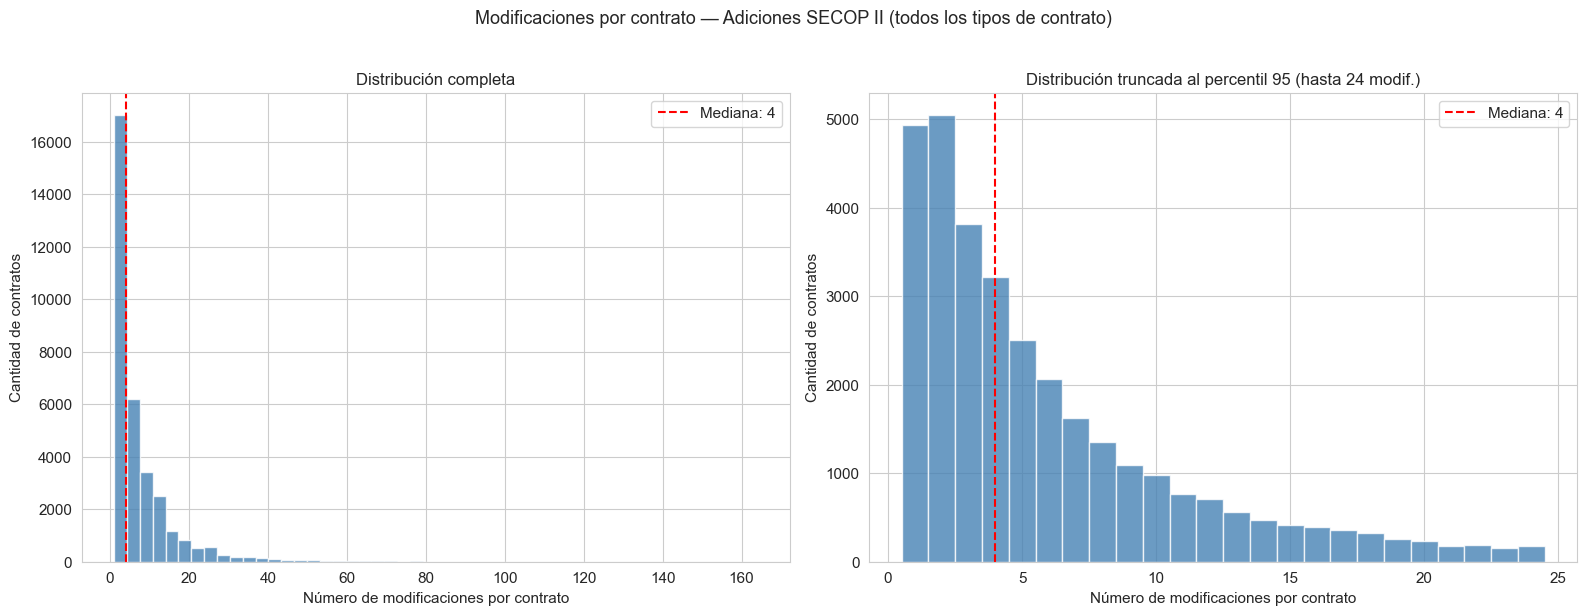

In [12]:
if contrato_col:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Histograma completo
    axes[0].hist(mods_per_contract.values, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0].set_xlabel('Número de modificaciones por contrato', fontsize=11)
    axes[0].set_ylabel('Cantidad de contratos', fontsize=11)
    axes[0].set_title('Distribución completa', fontsize=12)
    axes[0].axvline(mods_per_contract.median(), color='red', linestyle='--', label=f'Mediana: {mods_per_contract.median():.0f}')
    axes[0].legend()
    
    # Histograma truncado al percentil 95 para ver mejor la distribución central
    p95 = mods_per_contract.quantile(0.95)
    filtered = mods_per_contract[mods_per_contract <= p95]
    axes[1].hist(filtered.values, bins=range(1, int(p95)+2), color='steelblue', edgecolor='white', alpha=0.8, align='left')
    axes[1].set_xlabel('Número de modificaciones por contrato', fontsize=11)
    axes[1].set_ylabel('Cantidad de contratos', fontsize=11)
    axes[1].set_title(f'Distribución truncada al percentil 95 (hasta {p95:.0f} modif.)', fontsize=12)
    axes[1].axvline(mods_per_contract.median(), color='red', linestyle='--', label=f'Mediana: {mods_per_contract.median():.0f}')
    axes[1].legend()
    
    plt.suptitle('Modificaciones por contrato — Adiciones SECOP II (todos los tipos de contrato)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

### 6.2 Gráfico: Distribución agrupada (barras)

**Gráfico de barras** que agrupa los contratos por rangos de número de modificaciones.

- **Eje X**: Rango de modificaciones (1, 2, 3-4, 5-9, 10-19, 20-49, 50+)
- **Eje Y**: Cantidad de contratos en ese rango
- **Interpretación**: Permite ver rápidamente qué tan común es que un contrato tenga muchas vs pocas modificaciones.

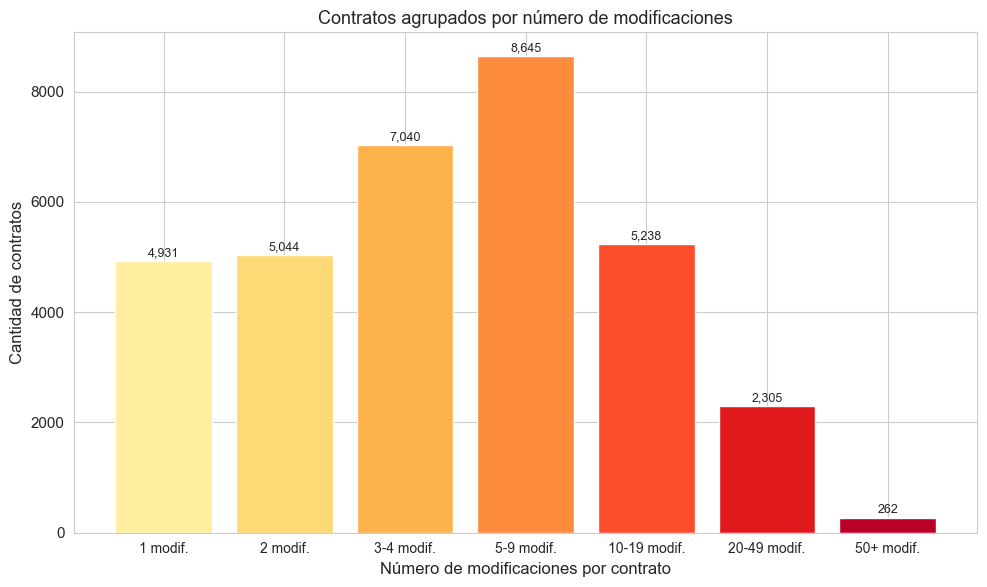

In [13]:
if contrato_col:
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(range(len(cat_counts)), cat_counts.values, color=sns.color_palette('YlOrRd', len(cat_counts)))
    ax.set_xticks(range(len(cat_counts)))
    ax.set_xticklabels(cat_counts.index, fontsize=10)
    ax.set_xlabel('Número de modificaciones por contrato', fontsize=12)
    ax.set_ylabel('Cantidad de contratos', fontsize=12)
    ax.set_title('Contratos agrupados por número de modificaciones', fontsize=13)
    
    for bar, val in zip(bars, cat_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + cat_counts.values.max()*0.01,
                f'{val:,}', ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()

## 7. Análisis temporal — `Fecha registro`

Convertimos la fecha de registro a datetime y analizamos la distribución temporal de las modificaciones.

Esto nos permite entender:
- ¿Desde cuándo se registran adiciones en SECOP II?
- ¿Hay tendencia creciente en modificaciones?
- ¿Hay estacionalidad (más modificaciones en ciertos meses)?

In [14]:
# Determinar el nombre exacto de la columna de fecha
fecha_col = None
for col in df.columns:
    if 'fecha' in col.lower():
        fecha_col = col
        break

if fecha_col is None:
    print('ADVERTENCIA: No se encontró columna de fecha.')
    print(f'Columnas disponibles: {df.columns.tolist()}')
else:
    print(f'=== ANÁLISIS TEMPORAL (columna: "{fecha_col}") ===')
    
    # Convertir a datetime
    df['fecha_parsed'] = pd.to_datetime(df[fecha_col], errors='coerce')
    
    n_parsed = df['fecha_parsed'].notna().sum()
    n_failed = df['fecha_parsed'].isna().sum()
    print(f'Fechas parseadas correctamente: {n_parsed:,} ({n_parsed/len(df)*100:.1f}%)')
    print(f'Fechas no parseadas: {n_failed:,} ({n_failed/len(df)*100:.1f}%)')
    print()
    
    if n_parsed > 0:
        print(f'Fecha más antigua: {df["fecha_parsed"].min()}')
        print(f'Fecha más reciente: {df["fecha_parsed"].max()}')
        print(f'Rango temporal: {(df["fecha_parsed"].max() - df["fecha_parsed"].min()).days:,} días')
        print()
        
        # Distribución por año
        df['anio'] = df['fecha_parsed'].dt.year
        print('=== MODIFICACIONES POR AÑO ===')
        year_counts = df['anio'].value_counts().sort_index()
        for year, count in year_counts.items():
            if pd.notna(year):
                pct = count / len(df) * 100
                print(f'  {int(year)}: {count:,} ({pct:.1f}%)')

=== ANÁLISIS TEMPORAL (columna: "fecharegistro") ===
Fechas parseadas correctamente: 249,037 (100.0%)
Fechas no parseadas: 0 (0.0%)

Fecha más antigua: 2016-01-01 00:00:00
Fecha más reciente: 2026-03-03 00:00:00
Rango temporal: 3,714 días

=== MODIFICACIONES POR AÑO ===
  2016: 9 (0.0%)
  2017: 179 (0.1%)
  2018: 1,719 (0.7%)
  2019: 4,048 (1.6%)
  2020: 8,212 (3.3%)
  2021: 11,826 (4.7%)
  2022: 25,540 (10.3%)
  2023: 65,546 (26.3%)
  2024: 47,836 (19.2%)
  2025: 44,634 (17.9%)
  2026: 39,488 (15.9%)


### 7.1 Gráfico: Evolución temporal de modificaciones

**Gráfico de líneas** que muestra la cantidad de modificaciones por mes a lo largo del tiempo.

- **Eje X (horizontal)**: Tiempo (mes/año). Cada punto representa un mes.
- **Eje Y (vertical)**: Cantidad de eventos de modificación registrados en ese mes.
- **Interpretación**: Una tendencia creciente sugiere que cada vez se registran más modificaciones (ya sea por más contratos o por mayor transparencia en el registro). Picos estacionales pueden indicar patrones de cierre fiscal o períodos de mayor actividad.

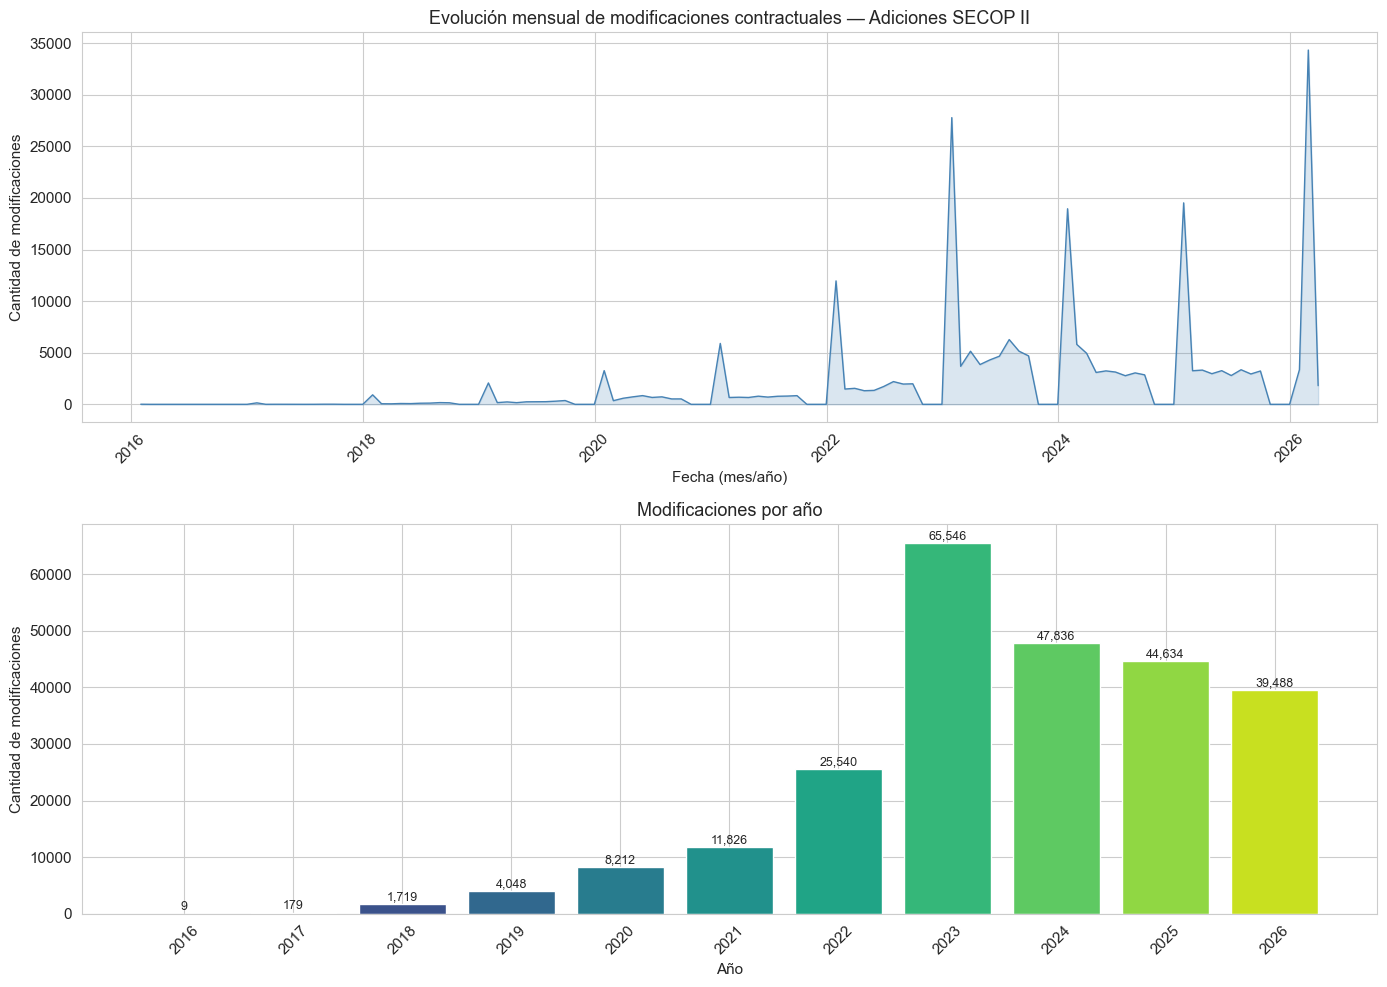

In [15]:
if fecha_col and n_parsed > 0:
    # Serie mensual
    monthly = df.set_index('fecha_parsed').resample('ME').size()
    monthly = monthly[monthly.index.notna()]
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Evolución mensual
    axes[0].plot(monthly.index, monthly.values, color='steelblue', linewidth=1)
    axes[0].fill_between(monthly.index, monthly.values, alpha=0.2, color='steelblue')
    axes[0].set_xlabel('Fecha (mes/año)', fontsize=11)
    axes[0].set_ylabel('Cantidad de modificaciones', fontsize=11)
    axes[0].set_title('Evolución mensual de modificaciones contractuales — Adiciones SECOP II', fontsize=13)
    axes[0].tick_params(axis='x', rotation=45)
    
    # Distribución por año (barras)
    year_data = df['anio'].dropna().astype(int).value_counts().sort_index()
    bars = axes[1].bar(year_data.index.astype(str), year_data.values, color=sns.color_palette('viridis', len(year_data)))
    axes[1].set_xlabel('Año', fontsize=11)
    axes[1].set_ylabel('Cantidad de modificaciones', fontsize=11)
    axes[1].set_title('Modificaciones por año', fontsize=13)
    axes[1].tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, year_data.values):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + year_data.values.max()*0.01,
                     f'{val:,}', ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
else:
    print('No se pueden generar gráficos temporales.')

### 7.2 Gráfico: Estacionalidad mensual

**Gráfico de barras** que muestra el promedio de modificaciones por mes del año (enero a diciembre), agregando todos los años.

- **Eje X**: Mes del año (1=Enero, 12=Diciembre)
- **Eje Y**: Promedio de modificaciones en ese mes (promediando todos los años)
- **Interpretación**: Si diciembre o enero tienen picos, puede deberse al cierre/apertura de vigencia fiscal. Si hay un valle en ciertos meses, puede indicar menor actividad administrativa.

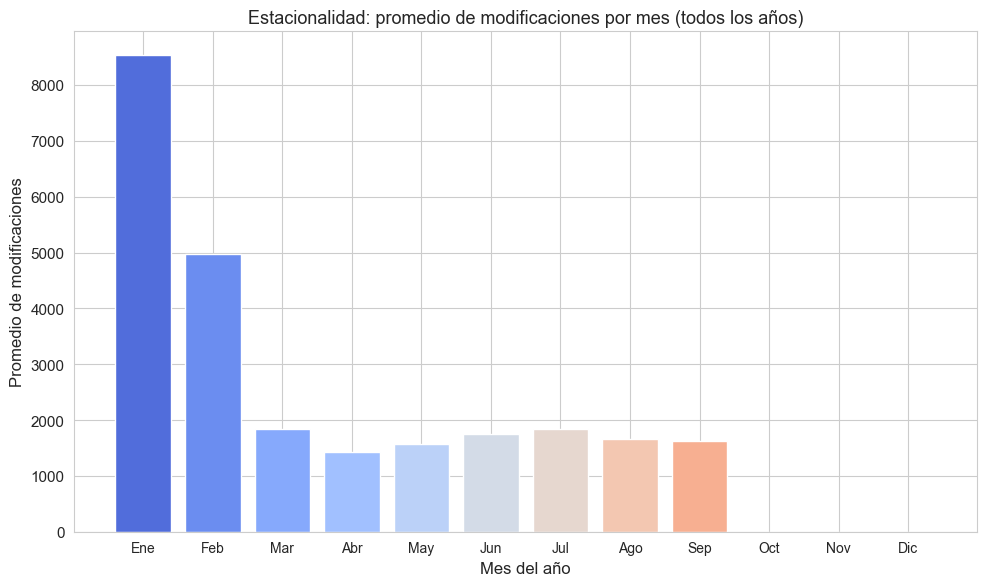

In [16]:
if fecha_col and n_parsed > 0:
    df['mes'] = df['fecha_parsed'].dt.month
    
    # Promedio mensual por año
    monthly_by_year = df.dropna(subset=['anio', 'mes']).groupby(['anio', 'mes']).size().reset_index(name='count')
    avg_by_month = monthly_by_year.groupby('mes')['count'].mean()
    
    month_names = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(range(1, 13), [avg_by_month.get(m, 0) for m in range(1, 13)],
                  color=sns.color_palette('coolwarm', 12))
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_names, fontsize=10)
    ax.set_xlabel('Mes del año', fontsize=12)
    ax.set_ylabel('Promedio de modificaciones', fontsize=12)
    ax.set_title('Estacionalidad: promedio de modificaciones por mes (todos los años)', fontsize=13)
    
    plt.tight_layout()
    plt.show()
else:
    print('No se puede analizar estacionalidad.')

## 8. Análisis de la columna `descripción`

La descripción contiene la justificación textual de cada modificación. Analizamos:
- Longitud de los textos
- Palabras más frecuentes
- Si hay textos vacíos o genéricos

Aunque no usaremos esta columna directamente como feature numérica, podría servir para:
- NLP / text mining futuro
- Validar la coherencia entre el `tipo` y la `descripción`
- Detectar patrones en las justificaciones

In [17]:
# Determinar el nombre exacto de la columna descripción
desc_col = None
for col in df.columns:
    if 'descripci' in col.lower() or 'descripcion' in col.lower():
        desc_col = col
        break

if desc_col is None:
    print('ADVERTENCIA: No se encontró columna de descripción.')
    print(f'Columnas disponibles: {df.columns.tolist()}')
else:
    print(f'=== ANÁLISIS DE DESCRIPCIONES (columna: "{desc_col}") ===')
    
    # Nulidad
    null_desc = df[desc_col].isna().sum()
    empty_desc = (df[desc_col].fillna('').str.strip() == '').sum()
    print(f'Descripciones nulas: {null_desc:,} ({null_desc/len(df)*100:.1f}%)')
    print(f'Descripciones vacías (incluyendo solo espacios): {empty_desc:,} ({empty_desc/len(df)*100:.1f}%)')
    print()
    
    # Longitud
    desc_lengths = df[desc_col].fillna('').str.len()
    print('=== LONGITUD DE LAS DESCRIPCIONES (caracteres) ===')
    print(f'  Mínimo: {desc_lengths.min()}')
    print(f'  Percentil 25: {desc_lengths.quantile(0.25):.0f}')
    print(f'  Mediana: {desc_lengths.median():.0f}')
    print(f'  Promedio: {desc_lengths.mean():.0f}')
    print(f'  Percentil 75: {desc_lengths.quantile(0.75):.0f}')
    print(f'  Percentil 95: {desc_lengths.quantile(0.95):.0f}')
    print(f'  Máximo: {desc_lengths.max():,}')
    print()
    
    # Descripciones más cortas (posiblemente genéricas)
    print('=== DESCRIPCIONES MÁS CORTAS (posiblemente genéricas) ===')
    short_desc = df[df[desc_col].fillna('').str.len() > 0][desc_col].value_counts().head(10)
    for desc, count in short_desc.items():
        preview = desc[:100] + ('...' if len(desc) > 100 else '')
        print(f'  [{count:,}x] "{preview}"')

=== ANÁLISIS DE DESCRIPCIONES (columna: "descripcion") ===
Descripciones nulas: 0 (0.0%)
Descripciones vacías (incluyendo solo espacios): 0 (0.0%)

=== LONGITUD DE LAS DESCRIPCIONES (caracteres) ===
  Mínimo: 1
  Percentil 25: 28
  Mediana: 73
  Promedio: 146
  Percentil 75: 156
  Percentil 95: 594
  Máximo: 1,200

=== DESCRIPCIONES MÁS CORTAS (posiblemente genéricas) ===
  [28,568x] "Sin Descripción"
  [904x] "PRORROGA NO 1"
  [714x] "ACTA DE LIQUIDACION"
  [462x] "ACTA DE REINICIO"
  [455x] "PRORROGA NO 2"
  [421x] "REINICIO"
  [420x] "PRORROGA"
  [412x] "CONFORME A LA JUSTIFICACIoN REMITIDA POR EL SUPERVISOR DEL CONTRATO; SE DA TRAMITE A LA PRESENTE PRo..."
  [392x] "SE FINALIZA EJECUCIoN DEL CONTRATO CONFOME AL ACTA DE RECIBO DEFINITIVO."
  [345x] "LIQUIDACION"


### 8.1 Gráfico: Distribución de longitud de descripciones

**Histograma** que muestra la distribución de la longitud (en caracteres) de las descripciones de las modificaciones.

- **Eje X (horizontal)**: Longitud de la descripción en caracteres. Por ejemplo, x=500 significa una descripción de 500 caracteres.
- **Eje Y (vertical)**: Cantidad de registros con esa longitud de descripción.
- **Interpretación**: Si hay un pico en longitudes muy cortas, puede haber muchas descripciones genéricas o vacías. Una distribución amplia indica variabilidad en el nivel de detalle de las justificaciones.

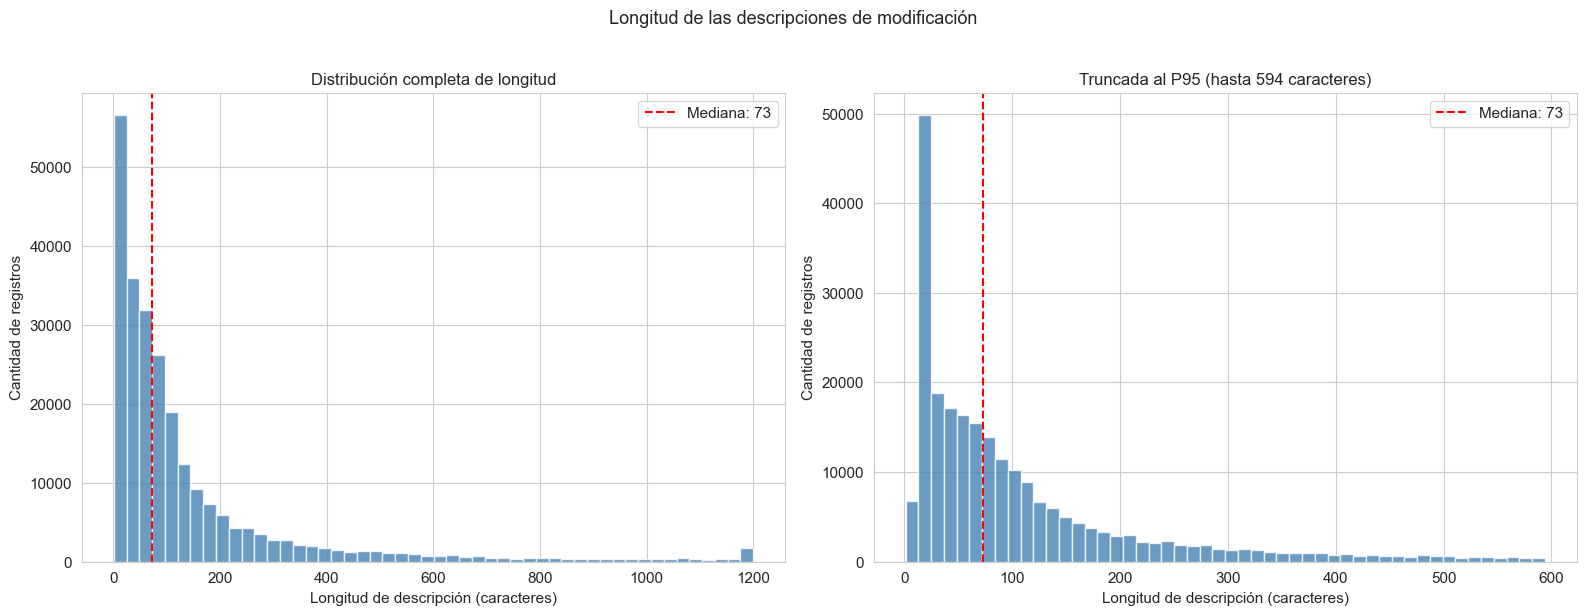

In [18]:
if desc_col:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Distribución completa
    axes[0].hist(desc_lengths[desc_lengths > 0].values, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0].set_xlabel('Longitud de descripción (caracteres)', fontsize=11)
    axes[0].set_ylabel('Cantidad de registros', fontsize=11)
    axes[0].set_title('Distribución completa de longitud', fontsize=12)
    axes[0].axvline(desc_lengths.median(), color='red', linestyle='--', label=f'Mediana: {desc_lengths.median():.0f}')
    axes[0].legend()
    
    # Truncada al percentil 95
    p95_len = desc_lengths.quantile(0.95)
    filtered_len = desc_lengths[(desc_lengths > 0) & (desc_lengths <= p95_len)]
    axes[1].hist(filtered_len.values, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[1].set_xlabel('Longitud de descripción (caracteres)', fontsize=11)
    axes[1].set_ylabel('Cantidad de registros', fontsize=11)
    axes[1].set_title(f'Truncada al P95 (hasta {p95_len:.0f} caracteres)', fontsize=12)
    axes[1].axvline(desc_lengths.median(), color='red', linestyle='--', label=f'Mediana: {desc_lengths.median():.0f}')
    axes[1].legend()
    
    plt.suptitle('Longitud de las descripciones de modificación', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

### 8.2 Palabras más frecuentes en las descripciones

Extraemos las palabras más frecuentes para identificar patrones en las justificaciones de las modificaciones. Excluimos stopwords comunes del español.

=== TOP 30 PALABRAS MÁS FRECUENTES ===
  contrato: 156,362
  prorroga: 50,561
  acta: 45,787
  suspension: 43,087
  obra: 42,807
  ejecucion: 32,358
  plazo: 31,322
  presente: 29,097
  descripción: 28,568
  modificacion: 28,560
  fecha: 28,167
  acuerdo: 24,717
  solicitud: 24,205
  contratista: 22,349
  liquidacion: 20,854
  terminacion: 19,173
  adicion: 18,454
  convenio: 18,117
  realiza: 18,037
  documentos: 17,653
  valor: 17,298
  reinicio: 17,213
  mediante: 14,513
  dias: 14,227
  cuenta: 13,776
  prorrogar: 13,317
  procede: 13,168
  conformidad: 13,157
  supervisor: 13,123
  contractual: 12,086


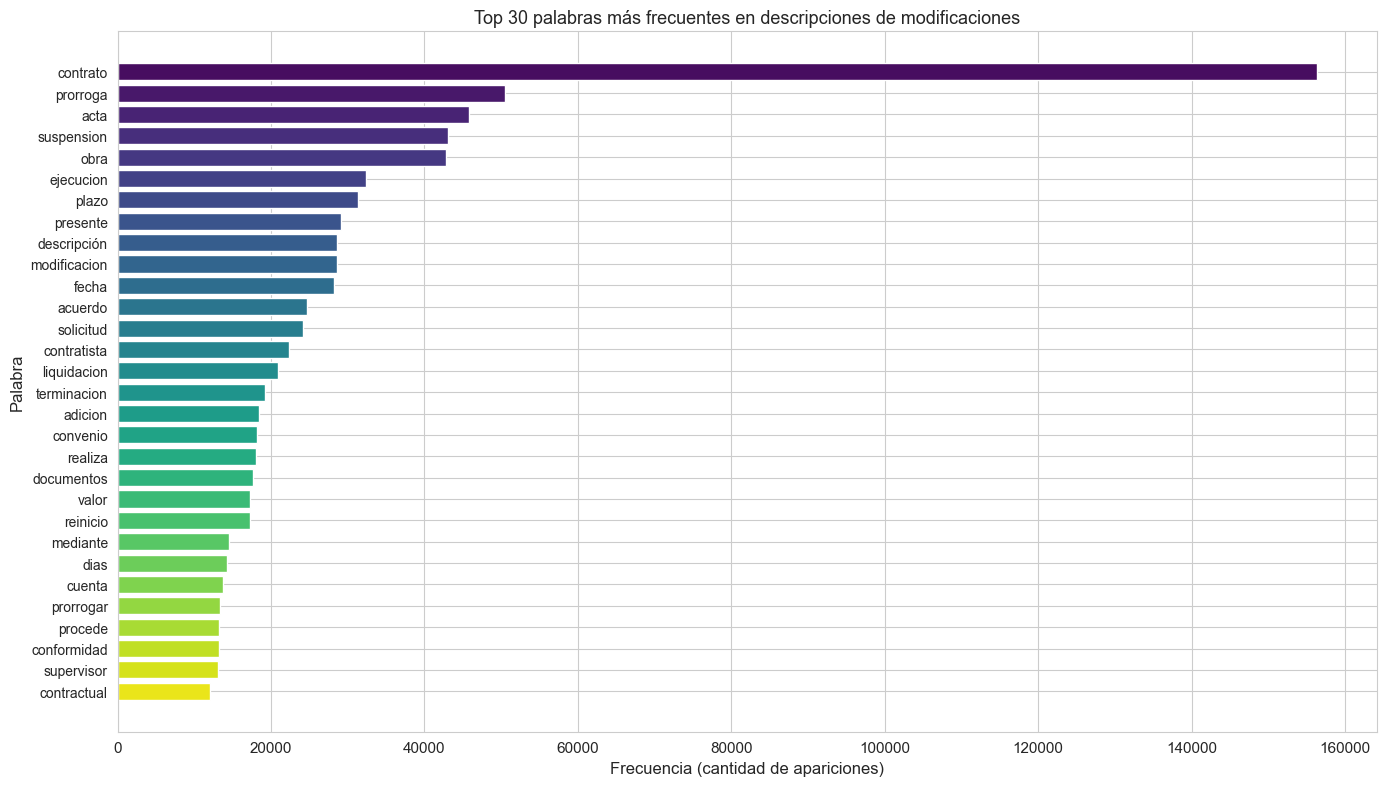

In [19]:
if desc_col:
    # Stopwords básicas del español
    stopwords_es = {'de', 'la', 'el', 'en', 'y', 'a', 'los', 'del', 'las', 'un', 'por', 'con',
                    'una', 'su', 'para', 'es', 'al', 'lo', 'como', 'se', 'no', 'que', 'o',
                    'más', 'pero', 'sus', 'le', 'ya', 'fue', 'este', 'ha', 'si', 'porque',
                    'son', 'entre', 'está', 'ser', 'sin', 'sobre', 'tiene', 'desde', 'todo',
                    'nos', 'durante', 'todos', 'uno', 'les', 'ni', 'contra', 'otros', 'ese',
                    'eso', 'ante', 'ellos', 'e', 'esto', 'me', 'hasta', 'hay', 'donde', 'quien',
                    'partir', 'cuando', 'cual', 'vez', 'cada', 'dicho', 'dem', 'asi'}
    
    # Tokenizar y contar
    all_words = []
    for text in df[desc_col].dropna():
        words = re.findall(r'[a-záéíóúñü]+', str(text).lower())
        all_words.extend([w for w in words if w not in stopwords_es and len(w) > 2])
    
    word_counts = Counter(all_words)
    top_30 = word_counts.most_common(30)
    
    print('=== TOP 30 PALABRAS MÁS FRECUENTES ===')
    for word, count in top_30:
        print(f'  {word}: {count:,}')
    
    # Gráfico
    fig, ax = plt.subplots(figsize=(14, 8))
    words, counts = zip(*top_30)
    bars = ax.barh(range(len(words)), counts, color=sns.color_palette('viridis', len(words)))
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=10)
    ax.set_xlabel('Frecuencia (cantidad de apariciones)', fontsize=12)
    ax.set_ylabel('Palabra', fontsize=12)
    ax.set_title('Top 30 palabras más frecuentes en descripciones de modificaciones', fontsize=13)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## 9. Perfil de modificaciones por contrato (pivot)

Para cada contrato de Obra con adiciones, contamos cuántas modificaciones tiene de cada tipo. Esto será clave para construir las **variables target**:
- `n_adiciones_valor`: cantidad de adiciones en valor -> indicador de sobrecosto
- `n_prorrogas`: cantidad de prórrogas -> indicador de extensión de plazo
- `tiene_adicion_valor`: binaria, tuvo al menos una adición en valor?
- `tiene_prorroga`: binaria, tuvo al menos una prórroga?

In [20]:
if tipo_col and contrato_col and len(df) > 0:
    # Pivot: contratos x tipos de modificación
    pivot = df.groupby([contrato_col, tipo_col]).size().unstack(fill_value=0)
    print(f'=== PERFIL DE MODIFICACIONES POR CONTRATO DE OBRA ===')
    print(f'Contratos con adiciones: {len(pivot):,}')
    print(f'Total contratos de Obra (del parquet): {len(obra_ids):,}')
    print(f'Porcentaje con al menos una adicion: {len(pivot)/len(obra_ids)*100:.1f}%')
    print()
    
    print('Columnas del pivot (tipos de modificacion):')
    for col in pivot.columns:
        n_contracts = (pivot[col] > 0).sum()
        pct = n_contracts / len(pivot) * 100
        print(f'  {col}: {n_contracts:,} contratos lo tienen ({pct:.1f}%)')
    print()
    
    # Estadísticas descriptivas del pivot
    print('Estadisticas del pivot (modificaciones por contrato):')
    print(pivot.describe().round(2).to_string())

=== PERFIL DE MODIFICACIONES POR CONTRATO DE OBRA ===
Contratos con adiciones: 33,465
Total contratos de Obra (del parquet): 48,331
Porcentaje con al menos una adicion: 69.2%

Columnas del pivot (tipos de modificacion):
  ADICION EN EL VALOR: 4,465 contratos lo tienen (13.3%)
  CESION: 496 contratos lo tienen (1.5%)
  CONCLUSION: 5,087 contratos lo tienen (15.2%)
  EXTENSION: 2 contratos lo tienen (0.0%)
  MODIFICACION GENERAL: 25,583 contratos lo tienen (76.4%)
  No definido: 18,523 contratos lo tienen (55.4%)
  REACTIVACIoN: 9,174 contratos lo tienen (27.4%)
  SUSPENSIoN: 8,275 contratos lo tienen (24.7%)

Estadisticas del pivot (modificaciones por contrato):
tipo   ADICION EN EL VALOR    CESION  CONCLUSION  EXTENSION  MODIFICACION GENERAL  No definido  REACTIVACIoN  SUSPENSIoN
count             33465.00  33465.00    33465.00   33465.00              33465.00     33465.00      33465.00    33465.00
mean                  0.23      0.03        0.32       0.00                  3.73       

## 10. Resumen de calidad

Resumen consolidado de la calidad del dataset de adiciones, incluyendo volumetría, duplicados, nulidad e integración con la fuente madre.

In [21]:
print('=' * 70)
print('RESUMEN DE CALIDAD — DATASET ADICIONES SECOP II (OBRA)')
print('=' * 70)
print()

print('1. VOLUMETRÍA')
print(f'   Registros descargados (solo Obra): {len(df):,}')
if contrato_col:
    print(f'   Contratos de Obra con adiciones: {df[contrato_col].nunique():,}')
    print(f'   Contratos de Obra totales (parquet): {len(obra_ids):,}')
    print(f'   Cobertura: {df[contrato_col].nunique()/len(obra_ids)*100:.1f}% de contratos de Obra tienen al menos una adición')
print()

print('2. DUPLICADOS')
if 'identificador' in df.columns:
    dup = df['identificador'].duplicated().sum()
    print(f'   Duplicados en identificador: {dup:,}')
dup_full = df.duplicated().sum()
print(f'   Filas completamente duplicadas: {dup_full:,}')
print()

print('3. NULIDAD')
for col in df.columns:
    if col in ['fecha_parsed', 'anio', 'mes']:
        continue
    nulls = df[col].isna().sum()
    pct = nulls / len(df) * 100
    print(f'   {col}: {nulls:,} nulos ({pct:.1f}%)')
print()

print('4. INTEGRACIÓN')
if contrato_col:
    print(f'   Llave: "{contrato_col}" (adiciones) = "id_contrato" (contratosElectronicos)')
    print(f'   Descarga filtrada directamente por IDs de contratos de Obra')
    print(f'   Contratos de Obra con adiciones: {df[contrato_col].nunique():,} de {len(obra_ids):,}')
print()

print('5. OBSERVACIONES CLAVE')
print('   - Dataset con solo 5 columnas (estructura simple)')
print('   - Campo "descripción" es texto libre (potencial para NLP futuro)')
print('   - La columna "tipo" es clave para construir targets de adición en valor y prórroga')
print('   - No todos los contratos de Obra tienen adiciones registradas')
print('   - Para el modelo: los contratos SIN adiciones también son información (target=0)')

RESUMEN DE CALIDAD — DATASET ADICIONES SECOP II (OBRA)

1. VOLUMETRÍA
   Registros descargados (solo Obra): 249,037
   Contratos de Obra con adiciones: 33,465
   Contratos de Obra totales (parquet): 48,331
   Cobertura: 69.2% de contratos de Obra tienen al menos una adición

2. DUPLICADOS
   Duplicados en identificador: 105,836
   Filas completamente duplicadas: 96,942

3. NULIDAD
   identificador: 0 nulos (0.0%)
   id_contrato: 0 nulos (0.0%)
   tipo: 0 nulos (0.0%)
   descripcion: 0 nulos (0.0%)
   fecharegistro: 0 nulos (0.0%)

4. INTEGRACIÓN
   Llave: "id_contrato" (adiciones) = "id_contrato" (contratosElectronicos)
   Descarga filtrada directamente por IDs de contratos de Obra
   Contratos de Obra con adiciones: 33,465 de 48,331

5. OBSERVACIONES CLAVE
   - Dataset con solo 5 columnas (estructura simple)
   - Campo "descripción" es texto libre (potencial para NLP futuro)
   - La columna "tipo" es clave para construir targets de adición en valor y prórroga
   - No todos los contrat

## 11. Clasificación de columnas y variables para modelado

Aunque este dataset tiene solo 5 columnas, su valor está en las **variables derivadas** que podemos construir al agregarlo a nivel de contrato. Clasificamos las columnas originales y proponemos las variables derivadas para el modelo.

In [22]:
print('=== CLASIFICACIÓN DE COLUMNAS — ADICIONES SECOP II ===')
print()
print('COLUMNAS ORIGINALES:')
print('-' * 75)
print(f'  {"Columna":<25} {"Tipo":<12} {"Rol para modelado"}')
print('-' * 75)

col_roles = [
    ('identificador', 'Texto', 'ID/Llave - PK del evento de modificación'),
    ('id_contrato', 'Texto', 'FK - Llave de integración con contratosElectronicos'),
    ('tipo', 'Texto', 'Feature categórica / Criterio para construir targets'),
    ('descripcion', 'Texto', 'Texto libre - Potencial para NLP futuro'),
    ('fecha_registro', 'Timestamp', 'Feature temporal - Fecha de la modificación'),
]

for col_name, col_type, col_role in col_roles:
    # Buscar columna real que coincida
    matched = False
    for real_col in df.columns:
        if real_col.lower().replace(' ', '_') == col_name or col_name in real_col.lower():
            print(f'  {real_col:<25} {col_type:<12} {col_role}')
            matched = True
            break
    if not matched and col_name not in ['fecha_parsed', 'anio', 'mes']:
        print(f'  {col_name:<25} {col_type:<12} {col_role}')

print()
print('VARIABLES DERIVADAS PROPUESTAS (al agregar por contrato):')
print('-' * 75)
print(f'  {"Variable":<28} {"Tipo":<10} {"Construcción":<35} {"Rol"}')
print('-' * 75)

derivadas = [
    ('n_modificaciones_total', 'Numérica', 'COUNT(*) por contrato', 'Feature'),
    ('n_adiciones_valor', 'Numérica', 'COUNT WHERE tipo=adición valor', 'Feature/Target'),
    ('n_prorrogas', 'Numérica', 'COUNT WHERE tipo=prórroga', 'Feature/Target'),
    ('tiene_adicion_valor', 'Binaria', '1 si n_adiciones_valor > 0', 'Target'),
    ('tiene_prorroga', 'Binaria', '1 si n_prorrogas > 0', 'Target'),
    ('n_tipos_distintos', 'Numérica', 'NUNIQUE(tipo) por contrato', 'Feature'),
    ('fecha_primera_modif', 'Fecha', 'MIN(fecha) por contrato', 'Feature'),
    ('fecha_ultima_modif', 'Fecha', 'MAX(fecha) por contrato', 'Feature'),
]

for var, tipo, construccion, rol in derivadas:
    print(f'  {var:<28} {tipo:<10} {construccion:<35} {rol}')

print()
print('NOTA SOBRE LEAKAGE:')
print('  Las variables derivadas de adiciones ocurren DURANTE la ejecución.')
print('  Si el target es "tendrá sobrecostos?", usar n_adiciones como')
print('  feature sería leakage. Estas variables deben usarse como TARGET')
print('  o con un corte temporal definido.')

=== CLASIFICACIÓN DE COLUMNAS — ADICIONES SECOP II ===

COLUMNAS ORIGINALES:
---------------------------------------------------------------------------
  Columna                   Tipo         Rol para modelado
---------------------------------------------------------------------------
  identificador             Texto        ID/Llave - PK del evento de modificación
  id_contrato               Texto        FK - Llave de integración con contratosElectronicos
  tipo                      Texto        Feature categórica / Criterio para construir targets
  descripcion               Texto        Texto libre - Potencial para NLP futuro
  fecha_registro            Timestamp    Feature temporal - Fecha de la modificación

VARIABLES DERIVADAS PROPUESTAS (al agregar por contrato):
---------------------------------------------------------------------------
  Variable                     Tipo       Construcción                        Rol
------------------------------------------------------------

## 12. Guardado en Parquet

Guardamos el dataset de adiciones filtrado (solo contratos de Obra) en formato Parquet para uso posterior en la fase de integración.

## 13. Conclusiones y evaluación CRISP-DM

### Resumen de hallazgos

El dataset de **adiciones** es una fuente complementaria que registra eventos de modificación contractual. Aunque tiene solo 5 columnas, es estratégicamente importante porque:

1. **Contiene información directa sobre los targets**: Las adiciones en valor y las prórrogas son exactamente lo que queremos predecir.
2. **Relación N:1 con contratos**: Un contrato puede tener múltiples adiciones, lo que permite construir features agregados ricos.
3. **Complementa `dias_adicionados`**: Mientras que `contratosElectronicos` tiene `dias_adicionados` como dato final, las adiciones muestran el detalle de cada modificación individual.

### Posición dentro de CRISP-DM

- **Fase actual**: 2 — Comprensión de datos
- **Progreso**: 3 de 4 fuentes exploradas
- **Siguiente paso**: Explorar `proveedoresRegistrados` (notebook 04)

### Riesgos y consideraciones

- **Leakage temporal**: Las adiciones ocurren DURANTE la ejecución del contrato. Si usamos `n_modificaciones` como feature y queremos predecir `sobrecosto` al inicio del contrato, estaríamos usando información futura.
- **Solución propuesta**: Las variables derivadas de adiciones deben usarse como **TARGETS**, no como features. O, si se usan como features, solo incluir adiciones anteriores a un punto de corte temporal definido.
- **Cobertura parcial**: No todos los contratos de Obra tienen adiciones registradas. Para el modelado, estos contratos tendrán valores de 0 en las variables derivadas.

In [23]:
# Guardar dataset de adiciones de Obra
output_path = DATA_DIR + 'adiciones_obra.parquet'

# Eliminar columnas derivadas temporales antes de guardar
cols_to_save = [col for col in df.columns if col not in ['fecha_parsed', 'anio', 'mes']]
df[cols_to_save].to_parquet(output_path, index=False)

import os
file_size_mb = os.path.getsize(output_path) / (1024 * 1024)

print(f'Dataset guardado: {output_path}')
print(f'Registros: {len(df):,}')
print(f'Columnas: {len(cols_to_save)}')
print(f'Tamaño: {file_size_mb:.1f} MB')
print()
print('Columnas guardadas:')
for col in cols_to_save:
    print(f'  - {col}')

Dataset guardado: ../data/adiciones_obra.parquet
Registros: 249,037
Columnas: 5
Tamaño: 11.7 MB

Columnas guardadas:
  - identificador
  - id_contrato
  - tipo
  - descripcion
  - fecharegistro


In [24]:
print('=' * 70)
print('NOTEBOOK 03 — ADICIONES SECOP II — COMPLETADO')
print('=' * 70)
print()
print('Archivos generados:')
print(f'  - {output_path}')
print()
print('Siguiente paso: notebooks/04_proveedores.ipynb')

NOTEBOOK 03 — ADICIONES SECOP II — COMPLETADO

Archivos generados:
  - ../data/adiciones_obra.parquet

Siguiente paso: notebooks/04_proveedores.ipynb
